In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/251207_bed_date_cam0_area_stats.csv")
df.head()

,bed,date,n,mean_mm2,std_mm2,min_mm2,q25_mm2,median_mm2,q75_mm2,max_mm2
0,0,20251204,48,35588.257173,13894.737141,17218.820900,26139.358005,31277.998375,39811.404790,67000.20604
1,0,20251205,72,35766.596825,13987.874332,9007.722781,27234.583787,39230.057255,47133.368910,55371.30112
2,1,20251130,24,21233.692028,3252.937627,18313.006770,18898.030227,19979.437210,22702.159975,28831.61021
3,1,20251202,24,58351.615092,8325.023379,42000.255830,51693.933048,60606.923850,64128.410710,72356.05880
4,1,20251203,12,60089.626188,7269.142628,46230.644670,53699.906288,62708.244275,66100.047650,67923.59785


In [2]:
df["bed_date"] = df["bed"].astype(str) + "_" + df["date"].astype(str)
df.head()

,bed,date,n,mean_mm2,std_mm2,min_mm2,q25_mm2,median_mm2,q75_mm2,max_mm2,bed_date
0,0,20251204,48,35588.257173,13894.737141,17218.820900,26139.358005,31277.998375,39811.404790,67000.20604,0_20251204
1,0,20251205,72,35766.596825,13987.874332,9007.722781,27234.583787,39230.057255,47133.368910,55371.30112,0_20251205
2,1,20251130,24,21233.692028,3252.937627,18313.006770,18898.030227,19979.437210,22702.159975,28831.61021,1_20251130
3,1,20251202,24,58351.615092,8325.023379,42000.255830,51693.933048,60606.923850,64128.410710,72356.05880,1_20251202
4,1,20251203,12,60089.626188,7269.142628,46230.644670,53699.906288,62708.244275,66100.047650,67923.59785,1_20251203


### Manus 말대로 시각화 하기


1.   기본 설정 및 데이터 로딩
2.   정규분포 분석: 기본통계분석
3.   베드별 분석
4.   상추별 분석
5.   이상치 탐지
6.   모델 정제도 평가
7.   통합 분석 실행 스크립트
8. 고급 분석 기법
9. 결과 저장 및 내보내기

### 1. 기본 설정 및 데이터 로딩




In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson, kstest
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
area_data = df['mean_mm2'].dropna()

print(f"총 레코드: {len(df)}")
print(f"고유 베드: {df['bed'].nunique()}")
print(f"날짜 베드: {df['bed_date'].nunique()}")

총 레코드: 419
고유 베드: 96
날짜 베드: 419


###2. 정규분포 분석


2.1.   기본 통계 및 정규성 검정\
2.2.   정규분포 시각화\




In [7]:
# 2.1 기본통계 및 정규성 검정

# User's requested modification: Analyze df['bed']'s 'mean_mm2' for mean, median, std, skew, kurtosis in DataFrame format
def analyze_bed_mean_mm2_stats(dataframe):
    """
    Groups the dataframe by 'bed' and calculates mean, median, std, skew, and kurtosis
    for 'mean_mm2' for each bed, returning the results in a DataFrame.
    """
    print("\n" + "=" * 60)
    print("베드별 mean_mm2 통계 분석")
    print("=" * 60)

    bed_mean_mm2_stats = dataframe.groupby('bed')['mean_mm2'].agg(
        mean='mean',
        median='median',
        std='std',
        skew=lambda x: stats.skew(x.dropna()), # Use dropna() as skew/kurtosis can fail on NaN
        kurtosis=lambda x: stats.kurtosis(x.dropna())
    ).round(2)

    print("\n베드별 mean_mm2 통계:")
    print(bed_mean_mm2_stats.head()) # print head for brevity

    return bed_mean_mm2_stats

bed_mean_mm2_analysis_df = analyze_bed_mean_mm2_stats(df)
display(bed_mean_mm2_analysis_df)


베드별 mean_mm2 통계 분석

베드별 mean_mm2 통계:
         mean    median       std  skew  kurtosis
bed                                              
0    35677.43  35677.43    126.11  0.00     -2.00
1    42120.05  41041.12  15413.33 -0.03     -1.38
2    48111.52  57734.50  16166.02 -0.54     -1.48
3    36572.57  29448.47  21255.26  0.48     -1.53
4    44410.40  51533.17  21584.79 -1.23     -0.14


,mean,median,std,skew,kurtosis
bed,,,,,
0,35677.43,35677.43,126.11,0.00,-2.00
1,42120.05,41041.12,15413.33,-0.03,-1.38
2,48111.52,57734.50,16166.02,-0.54,-1.48
3,36572.57,29448.47,21255.26,0.48,-1.53
4,44410.40,51533.17,21584.79,-1.23,-0.14
...,...,...,...,...,...
91,43010.64,52635.46,23147.19,-1.13,-0.32
92,45004.49,51147.88,11936.14,-1.12,-0.35
93,46283.24,45853.88,2057.58,0.37,-1.50


In [10]:
import pandas as pd

# date가 문자열이면 정렬 가능한 YYYYMMDD라 OK. 혹시 몰라 int로 통일
df["date"] = df["date"].astype(int)

# bed별 마지막 날짜 행 추출
last = df.loc[df.groupby("bed")["date"].idxmax()].copy()

# 상/하위 10% 경계
q10 = last["mean_mm2"].quantile(0.10)
q90 = last["mean_mm2"].quantile(0.90)

last["is_extreme"] = (last["mean_mm2"] <= q10) | (last["mean_mm2"] >= q90)
last = last.sort_values("bed").reset_index(drop=True)


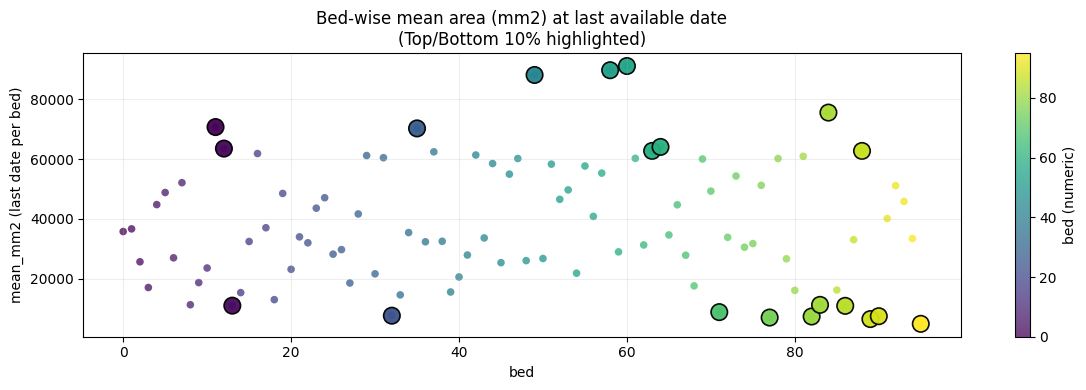

In [11]:
import matplotlib.pyplot as plt

x = last["bed"].astype(int).to_numpy()
y = last["mean_mm2"].to_numpy()

# 기본 점(얇게)
plt.figure(figsize=(12, 4))
sc = plt.scatter(
    x, y,
    c=x,              # bed 숫자값으로 색 매핑 (연속 컬러맵)
    cmap="viridis",
    s=30, alpha=0.75,
    linewidths=0
)

# 상/하위 10%만 "굵은 점"으로 덧그리기
ext = last["is_extreme"].to_numpy()
plt.scatter(
    x[ext], y[ext],
    c=x[ext],
    cmap="viridis",
    s=140,            # 굵게(크게)
    alpha=0.95,
    edgecolors="black",
    linewidths=1.2
)

plt.colorbar(sc, label="bed (numeric)")
plt.xlabel("bed")
plt.ylabel("mean_mm2 (last date per bed)")
plt.title("Bed-wise mean area (mm2) at last available date\n(Top/Bottom 10% highlighted)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


###3. 베드별 분석


1.   베드별 통계
2.   베드별 시각화




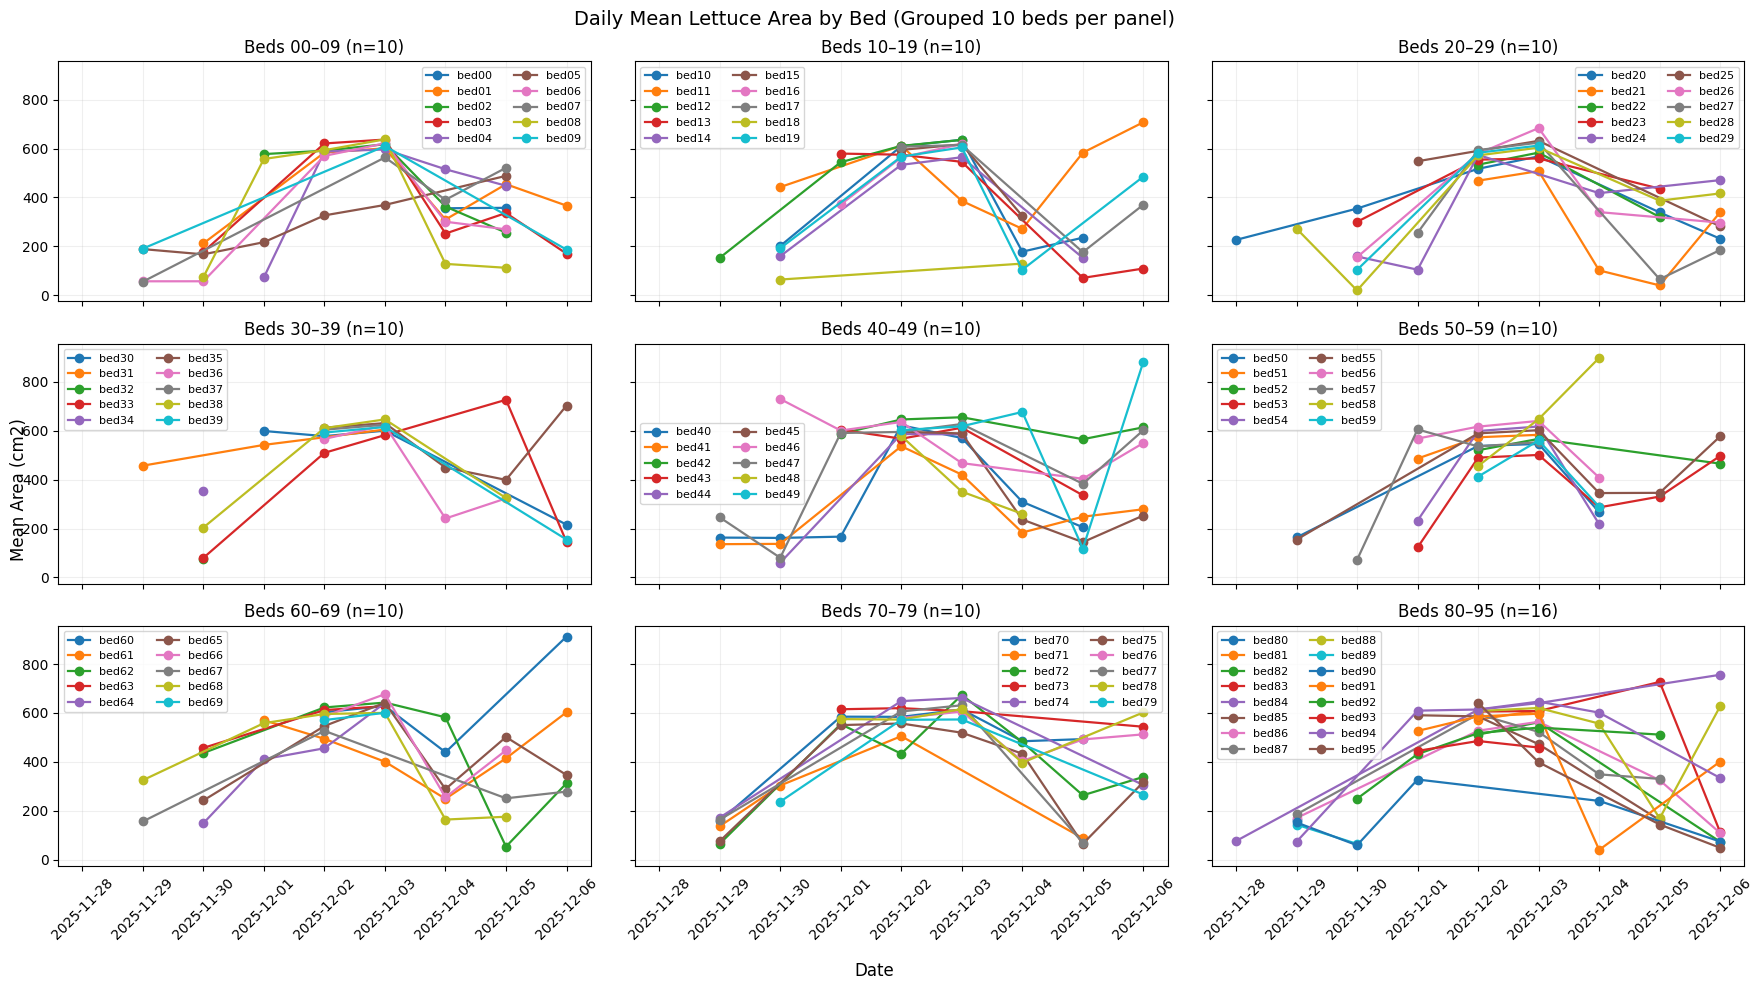

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 설정 ======
show_std = False   # True면 ±1 std 밴드도 그림(10개 라인+밴드라 좀 복잡해질 수 있음)
use_unit = "cm2"   # "mm2" 또는 "cm2"

# ====== 1) 날짜/단위 정리 ======
tmp = df.copy()

# date: YYYYMMDD -> datetime
tmp["date"] = pd.to_datetime(tmp["date"].astype(str), format="%Y%m%d")

# 사용할 y 컬럼 선택
if use_unit == "cm2":
    if "mean_cm2" in tmp.columns:
        y_mean = "mean_cm2"
        # std_cm2가 없다면 mm2 기준 std를 cm2로 변환 (1 cm2 = 100 mm2)
        if "std_cm2" not in tmp.columns and "std_mm2" in tmp.columns:
            tmp["std_cm2"] = tmp["std_mm2"] / 100.0
        y_std = "std_cm2" if "std_cm2" in tmp.columns else None
    else:
        # mean_cm2가 없으면 mean_mm2로부터 생성
        tmp["mean_cm2"] = tmp["mean_mm2"] / 100.0
        tmp["std_cm2"]  = tmp["std_mm2"] / 100.0 if "std_mm2" in tmp.columns else np.nan
        y_mean, y_std = "mean_cm2", ("std_cm2" if "std_mm2" in tmp.columns else None)
else:
    y_mean = "mean_mm2"
    y_std = "std_mm2" if "std_mm2" in tmp.columns else None

# bed 정렬
beds = np.sort(tmp["bed"].astype(int).unique())

# ====== 2) bed를 9개 그룹으로 나누기 (앞 8그룹: 10개, 마지막: 나머지) ======
groups = [beds[i*10:(i+1)*10] for i in range(8)]
groups.append(beds[80:])  # 마지막 그룹: 81번째 이후 전부 (95개면 15개 들어감)

# ====== 3) 3x3 subplot 그리기 ======
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, g in zip(axes, groups):
    if len(g) == 0:
        ax.axis("off")
        continue

    for b in g:
        sub = tmp[tmp["bed"].astype(int) == int(b)].sort_values("date")
        ax.plot(sub["date"], sub[y_mean], marker="o", linewidth=1.6, label=f"bed{int(b):02d}")

        # ±1 std 밴드(옵션)
        if show_std and (y_std is not None) and (y_std in sub.columns):
            m = sub[y_mean].to_numpy()
            s = sub[y_std].to_numpy()
            ax.fill_between(sub["date"], m - s, m + s, alpha=0.12)

    ax.set_title(f"Beds {int(g[0]):02d}–{int(g[-1]):02d} (n={len(g)})")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend(fontsize=8, ncol=2, frameon=True)

fig.suptitle("Daily Mean Lettuce Area by Bed (Grouped 10 beds per panel)", fontsize=14)
fig.supxlabel("Date")
fig.supylabel(f"Mean Area ({use_unit})")
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# =========================
# 0) 입력: 원본 df (개체별 면적 데이터)
#    df에는 최소한 lettuce_name, area_mm2(또는 area_cm2) 있어야 함
# =========================
agg=pd.read_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/251207_segmentation_area_mm2.csv")
raw = agg.copy()

# =========================
# 1) lettuce_name에서 date/cam 파싱 + cam0만
# =========================
pat = re.compile(
    r"^bed(?P<bed>\d{2,3})_(?P<date>\d{8})_(?P<time>\d{6})_(?P<cam>cam\d)_(?P<slot>\d{2})\.(png|jpg|jpeg)$",
    re.IGNORECASE
)

parsed = raw["lettuce_name"].astype(str).str.extract(pat)
raw = pd.concat([raw, parsed], axis=1)

raw["cam"] = raw["cam"].str.lower()
raw = raw[raw["cam"] == "cam0"].copy()

raw["date"] = pd.to_datetime(raw["date"].astype(str), format="%Y%m%d")

# 면적 단위: 캡쳐처럼 cm2로 맞춤
if "area_cm2" not in raw.columns:
    if "area_mm2" in raw.columns:
        raw["area_cm2"] = raw["area_mm2"] / 100.0
    else:
        raise ValueError("raw df에 area_cm2 또는 area_mm2 컬럼이 필요함")


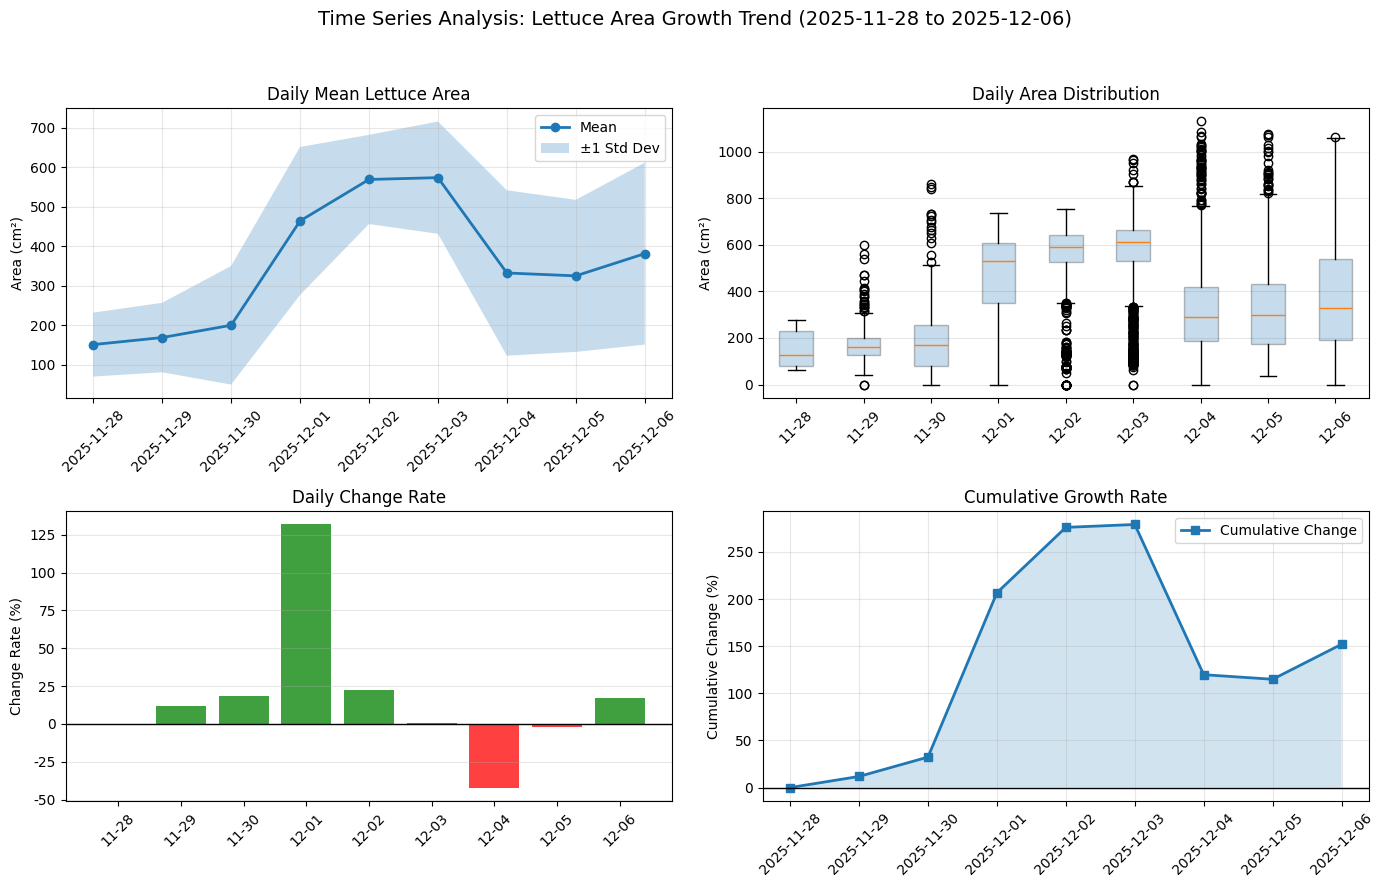

In [18]:

# =========================
# 2) 날짜별 통계 (전체 bed/개체 통합)
# =========================
daily = (raw.groupby("date")["area_cm2"]
         .agg(n="count", mean="mean", std="std")
         .reset_index()
         .sort_values("date")
        )

daily["pct_change"] = daily["mean"].pct_change() * 100
daily["cum_change"] = (daily["mean"] / daily["mean"].iloc[0] - 1) * 100

dates = daily["date"].tolist()
data_by_date = [raw.loc[raw["date"] == d, "area_cm2"].dropna().values for d in dates]

# =========================
# 3) 2x2 plot (캡쳐 스타일)
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
(ax1, ax2), (ax3, ax4) = axes

fig.suptitle(
    f"Time Series Analysis: Lettuce Area Growth Trend ({dates[0].date()} to {dates[-1].date()})",
    fontsize=14
)

# (1) Daily Mean + ±1 Std Dev
ax1.plot(daily["date"], daily["mean"], marker="o", linewidth=2, label="Mean")
ax1.fill_between(daily["date"], daily["mean"] - daily["std"], daily["mean"] + daily["std"],
                 alpha=0.25, label="±1 Std Dev")
ax1.set_title("Daily Mean Lettuce Area")
ax1.set_ylabel("Area (cm²)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# (2) Boxplot: Daily Area Distribution
bp = ax2.boxplot(
    data_by_date,
    labels=[d.strftime("%m-%d") for d in dates],
    showfliers=True,
    patch_artist=True
)
for box in bp["boxes"]:
    box.set_alpha(0.25)

ax2.set_title("Daily Area Distribution")
ax2.set_ylabel("Area (cm²)")
ax2.grid(True, axis="y", alpha=0.3)

# (3) Daily Change Rate: bar (green/red)
chg = daily["pct_change"].fillna(0).to_numpy()
colors = np.where(chg >= 0, "green", "red")
ax3.bar([d.strftime("%m-%d") for d in dates], chg, color=colors, alpha=0.75)
ax3.axhline(0, color="black", linewidth=1)
ax3.set_title("Daily Change Rate")
ax3.set_ylabel("Change Rate (%)")
ax3.grid(True, axis="y", alpha=0.3)

# (4) Cumulative Growth Rate: line + filled area
ax4.plot(daily["date"], daily["cum_change"], marker="s", linewidth=2, label="Cumulative Change")
ax4.fill_between(daily["date"], daily["cum_change"], 0, alpha=0.2)
ax4.axhline(0, color="black", linewidth=1)
ax4.set_title("Cumulative Growth Rate")
ax4.set_ylabel("Cumulative Change (%)")
ax4.grid(True, alpha=0.3)
ax4.legend()

# x축 회전 (겹침 방지)
for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis="x", labelrotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


###4. 성장률 분석



In [24]:
import numpy as np
import pandas as pd

tmp = df.copy()

# bed 정리
tmp["bed"] = tmp["bed"].astype(int)

# ✅ date 포맷이 YYYYMMDD든 2025-12-04든 섞여 있어도 자동 파싱
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")

# 혹시 파싱 실패가 있으면 확인
if tmp["date"].isna().any():
    bad = tmp[tmp["date"].isna()]
    print(f"[경고] date 파싱 실패 {len(bad)}개. 예시:", bad["date"].head(5).tolist())

tmp = tmp.sort_values(["bed", "date"])

# =========================
# 1) 날짜 start -> end 성장률
# =========================
start = tmp.loc[tmp.groupby("bed")["date"].idxmin(), ["bed", "date", "mean_mm2"]].rename(
    columns={"date": "start_date", "mean_mm2": "start_mean_mm2"}
)
end = tmp.loc[tmp.groupby("bed")["date"].idxmax(), ["bed", "date", "mean_mm2"]].rename(
    columns={"date": "end_date", "mean_mm2": "end_mean_mm2"}
)

date_growth = start.merge(end, on="bed", how="inner")
date_growth["date_range"] = (
    date_growth["start_date"].dt.strftime("%Y-%m-%d")
    + " ~ "
    + date_growth["end_date"].dt.strftime("%Y-%m-%d")
)
date_growth["date_days"] = (date_growth["end_date"] - date_growth["start_date"]).dt.days

date_growth["growth_start_end_%"] = np.where(
    date_growth["start_mean_mm2"] > 0,
    (date_growth["end_mean_mm2"] / date_growth["start_mean_mm2"] - 1) * 100,
    np.nan
)

# =========================
# 2) mean_mm2 min -> max 성장률
# =========================
minv = tmp.groupby("bed")["mean_mm2"].min().rename("min_mean_mm2")
maxv = tmp.groupby("bed")["mean_mm2"].max().rename("max_mean_mm2")
minmax = pd.concat([minv, maxv], axis=1).reset_index()

minmax["growth_min_max_%"] = np.where(
    minmax["min_mean_mm2"] > 0,
    (minmax["max_mean_mm2"] / minmax["min_mean_mm2"] - 1) * 100,
    np.nan
)

# =========================
# 3) 합쳐서 최종 표 만들기
# =========================
summary = (
    date_growth[["bed", "date_range", "date_days", "start_mean_mm2", "end_mean_mm2", "growth_start_end_%"]]
    .merge(minmax[["bed", "min_mean_mm2", "max_mean_mm2", "growth_min_max_%"]], on="bed", how="left")
    .sort_values("bed")
    .reset_index(drop=True)
)

# 보기 좋게 반올림
summary["start_mean_mm2"] = summary["start_mean_mm2"].round(2)
summary["end_mean_mm2"] = summary["end_mean_mm2"].round(2)
summary["min_mean_mm2"] = summary["min_mean_mm2"].round(2)
summary["max_mean_mm2"] = summary["max_mean_mm2"].round(2)
summary["growth_start_end_%"] = summary["growth_start_end_%"].round(2)
summary["growth_min_max_%"] = summary["growth_min_max_%"].round(2)

summary.head(20)
summary.to_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/251207_bed_growth_summary.csv", index=False, encoding="utf-8-sig")


###5. 이상치 탐지

1.   IQR 기반 이상치 탐지
2.   다중 이상치 탐지 방법 비교


In [25]:
# IQR 기반 이상치 탐지

def detect_outliers_iqr(data):
    """IQR 기반 이상치 탐지"""

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("=" * 60)
    print("이상치 탐지 (IQR 방법)")
    print("=" * 60)
    print(f"\nQ1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"하한: {lower_bound:.2f}")
    print(f"상한: {upper_bound:.2f}")

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    inliers = data[(data >= lower_bound) & (data <= upper_bound)]

    print(f"\n이상치: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"정상치: {len(inliers)} ({len(inliers)/len(data)*100:.2f}%)")

    return outliers, inliers, lower_bound, upper_bound

outliers, inliers, lower_bound, upper_bound = detect_outliers_iqr(area_data)

이상치 탐지 (IQR 방법)

Q1: 25293.72
Q3: 59489.06
IQR: 34195.34
하한: -25999.30
상한: 110782.08

이상치: 0 (0.00%)
정상치: 419 (100.00%)


###8. 생육 단게별 분층 분석


1.   생육 단계별 분층 분석
2.   베드 성능 등급화



In [28]:
def stratified_analysis_by_growth_stage(df):
    """생육 단계별 분층 분석"""

    # 면적 기반 생육 단계 분류
    q33 = df['mean_mm2'].quantile(0.33)
    q67 = df['mean_mm2'].quantile(0.67)

    early = df[df['mean_mm2'] <= q33]
    middle = df[(df['mean_mm2'] > q33) & (df['mean_mm2'] <= q67)]
    late = df[df['mean_mm2'] > q67]

    print("=" * 60)
    print("생육 단계별 분석")
    print("=" * 60)

    for stage_name, stage_data in [('초기', early), ('중기', middle), ('후기', late)]:
        print(f"\n{stage_name} 생육:")
        print(f"  레코드: {len(stage_data)}")
        print(f"  평균: {stage_data['mean_mm2'].mean():.2f}")
        print(f"  표준편차: {stage_data['mean_mm2'].std():.2f}")
        print(f"  CV: {stage_data['mean_mm2'].std()/stage_data['mean_mm2'].mean()*100:.2f}%")

        # 각 단계별 정규성 검정
        stat, p = normaltest(stage_data['mean_mm2'])
        normality = "정규분포" if p > 0.05 else "비정규분포"
        print(f"  정규성: {normality} (p={p:.6e})")

stratified_analysis_by_growth_stage(df)

생육 단계별 분석

초기 생육:
  레코드: 138
  평균: 17981.72
  표준편차: 8380.66
  CV: 46.61%
  정규성: 비정규분포 (p=7.684031e-08)

중기 생육:
  레코드: 143
  평균: 47641.77
  표준편차: 7940.98
  CV: 16.67%
  정규성: 비정규분포 (p=1.058926e-12)

후기 생육:
  레코드: 138
  평균: 62221.41
  표준편차: 5236.78
  CV: 8.42%
  정규성: 비정규분포 (p=3.371893e-29)
